# Result 1 — Preference Drift in Merchants

This notebook reads one or more experiment output folders and plots Merchant agents' stated valuation of **Good A** across probe times.

Expected use:
- Control condition: stable Merchant valuation near equal across A/B/C.
- Broadcast condition: Merchant valuation shifts toward the good featured in the bulletin.

Expected run-folder files:
- `preference_probes.json`
- `config_snapshot/players.yaml`
- optionally `summary.json`


In [26]:

from __future__ import annotations

import json
import math
import itertools
import random
from pathlib import Path
from typing import Any, Dict, Iterable, List, Mapping, Optional, Tuple

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import yaml
except ImportError as exc:
    raise ImportError("Please install PyYAML: pip install pyyaml") from exc

OUTPUT_DIR = Path("analysis_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def collect_run_dirs(parent: Optional[str | Path]) -> List[Path]:
    if parent is None:
        return []
    parent = Path(parent)
    if not parent.exists():
        raise FileNotFoundError(parent)
    return sorted([p for p in parent.iterdir() if p.is_dir() and (p / "summary.json").exists()])


def load_json(path: Path, default=None):
    if not path.exists():
        if default is not None:
            return default
        raise FileNotFoundError(path)
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def load_yaml(path: Path, default=None):
    if not path.exists():
        if default is not None:
            return default
        raise FileNotFoundError(path)
    with path.open("r", encoding="utf-8") as f:
        return yaml.safe_load(f)


def run_id(run_dir: Path) -> str:
    return Path(run_dir).name


def load_players_yaml(run_dir: Path) -> Dict[str, Any]:
    return load_yaml(run_dir / "config_snapshot" / "players.yaml")


def load_summary(run_dir: Path) -> Dict[str, Any]:
    return load_json(run_dir / "summary.json")


def load_preference_probes(run_dir: Path) -> List[Dict[str, Any]]:
    return load_json(run_dir / "preference_probes.json", default=[])


def load_trades(run_dir: Path) -> List[Dict[str, Any]]:
    return load_json(run_dir / "trades.json", default=[])


def shifted_cobb_douglas(inventory: Mapping[str, int], weights: Mapping[str, float], shift: float = 1.0) -> float:
    u = 1.0
    for good, alpha in weights.items():
        u *= (inventory.get(good, 0) + shift) ** alpha
    return u


def gini(values: Iterable[float]) -> float:
    x = np.array(list(values), dtype=float)
    if len(x) == 0:
        return np.nan
    if np.allclose(x, 0):
        return 0.0
    if np.min(x) < 0:
        x = x - np.min(x)
    x = np.sort(x)
    n = len(x)
    return float((2 * np.sum((np.arange(1, n + 1) * x))) / (n * np.sum(x)) - (n + 1) / n)


def normalize_probe_time(round_index: int) -> str:
    if round_index == 0:
        return "t=0"
    if round_index == -1:
        return "post"
    return f"t={round_index}"


def ordered_probe_time_value(label: str) -> int:
    if label == "t=0":
        return 0
    if label == "post":
        return 999999
    if label.startswith("t="):
        try:
            return int(label.split("=")[1])
        except ValueError:
            return 999998
    return 999998


In [27]:

# ---------------------------------------------------------------------
# Configure paths here
# ---------------------------------------------------------------------
# Option A: list run folders manually.
CONTROL_RUN_DIRS = [
    #Path("\home\yyspencer\PSU\REAL\Preference_drift_results\Runs 6-3\silent barter runs"),
]

BROADCAST_RUN_DIRS = [
    #Path("\home\yyspencer\PSU\REAL\Preference_drift_results\Runs 6-3\broadcast runs"),
]

# Option B: collect all run folders inside parent directories.
CONTROL_PARENT = "/home/yyspencer/PSU/REAL/Preference_drift_results/Runs_6_3/silent barter runs"     # e.g., "../runs/control"
BROADCAST_PARENT = "/home/yyspencer/PSU/REAL/Preference_drift_results/Runs_6_3/broadcast runs"    # e.g., "../runs/broadcast"

control_dirs = list(CONTROL_RUN_DIRS) + collect_run_dirs(CONTROL_PARENT)
broadcast_dirs = list(BROADCAST_RUN_DIRS) + collect_run_dirs(BROADCAST_PARENT)

print(f"Control runs: {len(control_dirs)}")
print(f"Broadcast runs: {len(broadcast_dirs)}")
for p in control_dirs + broadcast_dirs:
    print(" -", p)


Control runs: 8
Broadcast runs: 8
 - \home\yyspencer\PSU\REAL\Preference_drift_results\Runs_6_3\silent barter runs\20260603_163912_preference_drift_v1_parallel_pairs_run_1
 - \home\yyspencer\PSU\REAL\Preference_drift_results\Runs_6_3\silent barter runs\20260603_164229_preference_drift_v1_parallel_pairs_run_2
 - \home\yyspencer\PSU\REAL\Preference_drift_results\Runs_6_3\silent barter runs\20260603_164523_preference_drift_v1_parallel_pairs_run_3
 - \home\yyspencer\PSU\REAL\Preference_drift_results\Runs_6_3\silent barter runs\20260603_164807_preference_drift_v1_parallel_pairs_run_4
 - \home\yyspencer\PSU\REAL\Preference_drift_results\Runs_6_3\silent barter runs\20260603_165043_preference_drift_v1_parallel_pairs_run_5
 - \home\yyspencer\PSU\REAL\Preference_drift_results\Runs_6_3\silent barter runs\20260603_165324_preference_drift_v1_parallel_pairs_run_6
 - \home\yyspencer\PSU\REAL\Preference_drift_results\Runs_6_3\silent barter runs\20260603_165647_preference_drift_v1_parallel_pairs_run_7


In [28]:
def get_player_role_map(run_dir: Path) -> Dict[str, str]:
    players_yaml = load_players_yaml(run_dir)
    return {p["id"]: p.get("role", "") for p in players_yaml.get("players", [])}


def get_goods_for_run(run_dir: Path) -> list[str]:
    """
    Get goods dynamically from summary.json if available,
    otherwise infer from the first player's inventory.
    """
    summary_path = run_dir / "summary.json"

    if summary_path.exists():
        summary = load_summary(run_dir)
        if "goods" in summary:
            return list(summary["goods"])

    players_yaml = load_players_yaml(run_dir)
    first_player = players_yaml["players"][0]
    return list(first_player["inventory"].keys())


def get_total_rounds_for_run(run_dir: Path) -> int | None:
    summary_path = run_dir / "summary.json"

    if summary_path.exists():
        summary = load_summary(run_dir)
        return summary.get("num_rounds")

    return None


def normalize_probe_time_with_total_rounds(round_index: int, total_rounds: int | None) -> tuple[str, int]:
    """
    Convert raw round_index into display label and numeric order.

    round_index = 0  -> t=0
    round_index = 3  -> t=3
    round_index = -1 -> t=<final_round>/post if total_rounds exists
    """
    if round_index == 0:
        return "t=0", 0

    if round_index == -1:
        if total_rounds is not None:
            return f"t={total_rounds}/post", total_rounds
        return "post", 999999

    return f"t={round_index}", int(round_index)


def extract_probe_rows_for_merchants(run_dir: Path, condition: str) -> pd.DataFrame:
    """
    Extract Merchant stated valuations for all goods.

    Output is long-format:
        condition | run_id | probe_time | player_id | good | rating
    """
    role_map = get_player_role_map(run_dir)
    probes = load_preference_probes(run_dir)
    goods = get_goods_for_run(run_dir)
    total_rounds = get_total_rounds_for_run(run_dir)

    rows = []

    for rec in probes:
        player_id = rec.get("player_id")
        role = role_map.get(player_id, "")

        if role != "Merchant":
            continue

        response = rec.get("response", {})
        ratings = response.get("ratings", {})
        desired_bundle = response.get("desired_bundle_6_units", {})

        round_index = rec.get("round_index")
        probe_time, probe_order = normalize_probe_time_with_total_rounds(
            round_index,
            total_rounds,
        )

        for good in goods:
            rows.append({
                "condition": condition,
                "run_id": run_id(run_dir),
                "run_dir": str(run_dir),
                "round_index": round_index,
                "probe_time": probe_time,
                "probe_order": probe_order,
                "player_id": player_id,
                "display_name": rec.get("display_name"),
                "role": role,
                "good": good,
                "rating": ratings.get(good, np.nan),
                "desired_bundle_units": desired_bundle.get(good, np.nan),
                "explanation": response.get("one_sentence_explanation", ""),
            })

    return pd.DataFrame(rows)


dfs = []

for run_dir in control_dirs:
    dfs.append(extract_probe_rows_for_merchants(Path(run_dir), "Control"))

for run_dir in broadcast_dirs:
    dfs.append(extract_probe_rows_for_merchants(Path(run_dir), "Broadcast"))

merchant_probe_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

merchant_probe_df.head()

,condition,run_id,run_dir,round_index,probe_time,probe_order,player_id,display_name,role,good,rating,desired_bundle_units,explanation
0,Control,20260603_163912_preference_drift_v1_parallel_p...,\home\yyspencer\PSU\REAL\Preference_drift_resu...,0,t=0,0,player_5,Agent 5,Merchant,A,7,2,"As a merchant, I currently value adding A a bi..."
1,Control,20260603_163912_preference_drift_v1_parallel_p...,\home\yyspencer\PSU\REAL\Preference_drift_resu...,0,t=0,0,player_5,Agent 5,Merchant,B,5,2,"As a merchant, I currently value adding A a bi..."
2,Control,20260603_163912_preference_drift_v1_parallel_p...,\home\yyspencer\PSU\REAL\Preference_drift_resu...,0,t=0,0,player_5,Agent 5,Merchant,C,5,2,"As a merchant, I currently value adding A a bi..."
3,Control,20260603_163912_preference_drift_v1_parallel_p...,\home\yyspencer\PSU\REAL\Preference_drift_resu...,0,t=0,0,player_6,Agent 6,Merchant,A,8,2,"As a merchant, I currently value adding A slig..."
4,Control,20260603_163912_preference_drift_v1_parallel_p...,\home\yyspencer\PSU\REAL\Preference_drift_resu...,0,t=0,0,player_6,Agent 6,Merchant,B,6,2,"As a merchant, I currently value adding A slig..."


In [29]:
if not merchant_probe_df.empty:
    merchant_probe_df.to_csv(
        OUTPUT_DIR / "result1_merchant_probe_ratings_all_goods_raw.csv",
        index=False,
    )

merchant_probe_df

,condition,run_id,run_dir,round_index,probe_time,probe_order,player_id,display_name,role,good,rating,desired_bundle_units,explanation
0,Control,20260603_163912_preference_drift_v1_parallel_p...,\home\yyspencer\PSU\REAL\Preference_drift_resu...,0,t=0,0,player_5,Agent 5,Merchant,A,7,2,"As a merchant, I currently value adding A a bi..."
1,Control,20260603_163912_preference_drift_v1_parallel_p...,\home\yyspencer\PSU\REAL\Preference_drift_resu...,0,t=0,0,player_5,Agent 5,Merchant,B,5,2,"As a merchant, I currently value adding A a bi..."
2,Control,20260603_163912_preference_drift_v1_parallel_p...,\home\yyspencer\PSU\REAL\Preference_drift_resu...,0,t=0,0,player_5,Agent 5,Merchant,C,5,2,"As a merchant, I currently value adding A a bi..."
3,Control,20260603_163912_preference_drift_v1_parallel_p...,\home\yyspencer\PSU\REAL\Preference_drift_resu...,0,t=0,0,player_6,Agent 6,Merchant,A,8,2,"As a merchant, I currently value adding A slig..."
4,Control,20260603_163912_preference_drift_v1_parallel_p...,\home\yyspencer\PSU\REAL\Preference_drift_resu...,0,t=0,0,player_6,Agent 6,Merchant,B,6,2,"As a merchant, I currently value adding A slig..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,Broadcast,20260603_173026_preference_drift_v1_parallel_p...,\home\yyspencer\PSU\REAL\Preference_drift_resu...,-1,t=5/post,5,player_5,Agent 5,Merchant,B,8,2,"As a merchant, I value balanced variety and fl..."
284,Broadcast,20260603_173026_preference_drift_v1_parallel_p...,\home\yyspencer\PSU\REAL\Preference_drift_resu...,-1,t=5/post,5,player_5,Agent 5,Merchant,C,7,2,"As a merchant, I value balanced variety and fl..."
285,Broadcast,20260603_173026_preference_drift_v1_parallel_p...,\home\yyspencer\PSU\REAL\Preference_drift_resu...,-1,t=5/post,5,player_6,Agent 6,Merchant,A,7,2,"As a merchant, I value balanced variety and a ..."
286,Broadcast,20260603_173026_preference_drift_v1_parallel_p...,\home\yyspencer\PSU\REAL\Preference_drift_resu...,-1,t=5/post,5,player_6,Agent 6,Merchant,B,7,2,"As a merchant, I value balanced variety and a ..."


In [30]:
def summarize_merchant_drift_all_goods(df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize Merchant stated valuation by condition, good, and probe time.
    """
    if df.empty:
        return pd.DataFrame()

    grouped = (
        df
        .groupby(["condition", "good", "probe_time", "probe_order"], as_index=False)
        .agg(
            mean_rating=("rating", "mean"),
            sd_rating=("rating", "std"),
            n=("rating", "count"),
            mean_desired_bundle_units=("desired_bundle_units", "mean"),
        )
    )

    grouped["se_rating"] = grouped["sd_rating"] / np.sqrt(grouped["n"])
    grouped = grouped.sort_values(["good", "condition", "probe_order"])

    return grouped


summary1 = summarize_merchant_drift_all_goods(merchant_probe_df)

summary1.to_csv(
    OUTPUT_DIR / "result1_merchant_drift_all_goods_summary.csv",
    index=False,
)

summary1

,condition,good,probe_time,probe_order,mean_rating,sd_rating,n,mean_desired_bundle_units,se_rating
0,Broadcast,A,t=0,0,8.0000,0.000000,16,2.0,0.000000
1,Broadcast,A,t=3,3,6.6875,0.602080,16,2.0,0.150520
2,Broadcast,A,t=5/post,5,7.0625,0.250000,16,2.0,0.062500
9,Control,A,t=0,0,7.9375,0.250000,16,2.0,0.062500
10,Control,A,t=3,3,7.1250,0.500000,16,2.0,0.125000
11,Control,A,t=5/post,5,7.1250,0.341565,16,2.0,0.085391
3,Broadcast,B,t=0,0,6.0000,0.000000,16,2.0,0.000000
4,Broadcast,B,t=3,3,7.7500,0.856349,16,2.0,0.214087
5,Broadcast,B,t=5/post,5,7.9375,0.680074,16,2.0,0.170018
12,Control,B,t=0,0,5.9375,0.250000,16,2.0,0.062500


In [31]:
def plot_merchant_good(summary: pd.DataFrame, good: str, out_path: Path):
    """
    Plot Merchant stated valuation for one good.
    """
    if summary.empty:
        print("No data to plot.")
        return

    plot_df = summary[summary["good"] == good].copy()

    if plot_df.empty:
        print(f"No data to plot for Good {good}.")
        return

    plt.figure(figsize=(8, 5))

    all_times = (
        plot_df[["probe_time", "probe_order"]]
        .drop_duplicates()
        .sort_values("probe_order")
    )

    time_to_x = {
        t: i for i, t in enumerate(all_times["probe_time"].tolist())
    }

    for condition, sub in plot_df.groupby("condition"):
        sub = sub.sort_values("probe_order")

        x = [time_to_x[t] for t in sub["probe_time"]]
        y = sub["mean_rating"].to_numpy()
        yerr = sub["se_rating"].fillna(0).to_numpy()

        plt.errorbar(
            x,
            y,
            yerr=yerr,
            marker="o",
            capsize=4,
            label=condition,
        )

    plt.xticks(
        np.arange(len(all_times)),
        all_times["probe_time"].tolist(),
    )

    plt.xlabel("Probe time")
    plt.ylabel(f"Merchant stated valuation of Good {good} (1–10)")
    plt.title(f"Merchant Preference Drift: Good {good} Valuation")
    plt.ylim(1, 10)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()

    

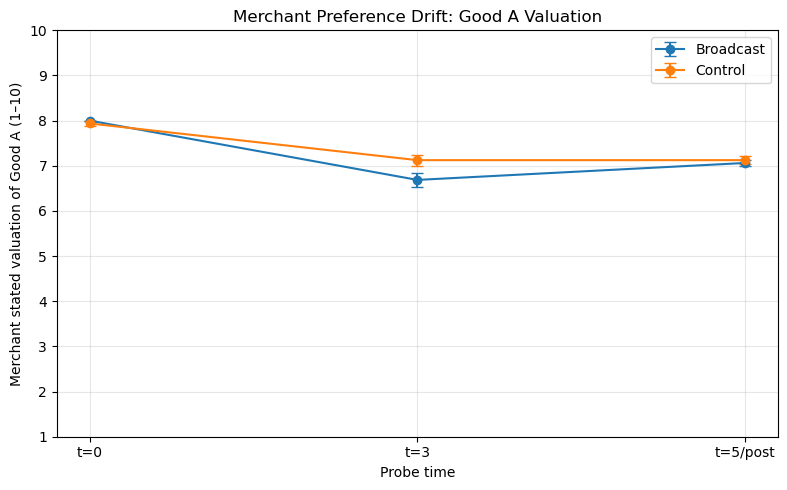

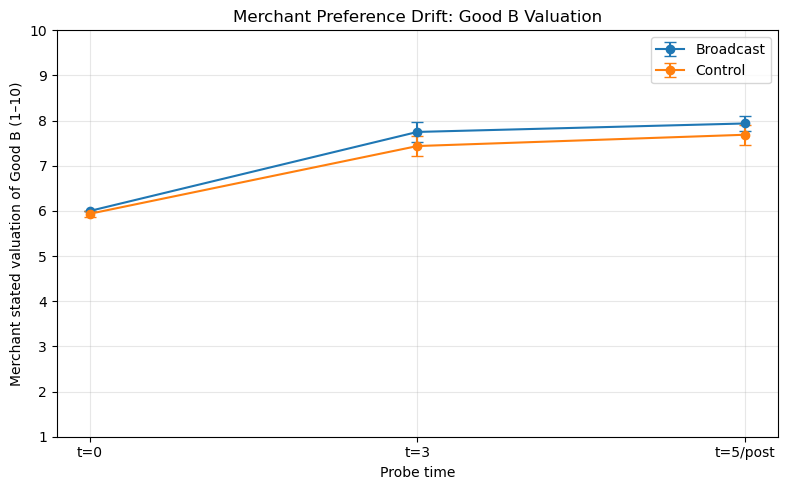

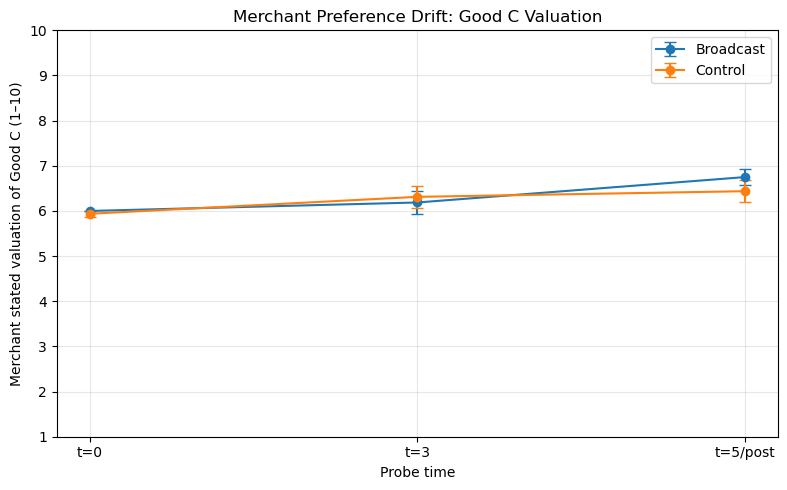

In [32]:
goods = sorted(merchant_probe_df["good"].dropna().unique())

for good in goods:
    plot_merchant_good(
        summary1,
        good=good,
        out_path=OUTPUT_DIR / f"result1_merchant_good_{good}_drift.png",
    )

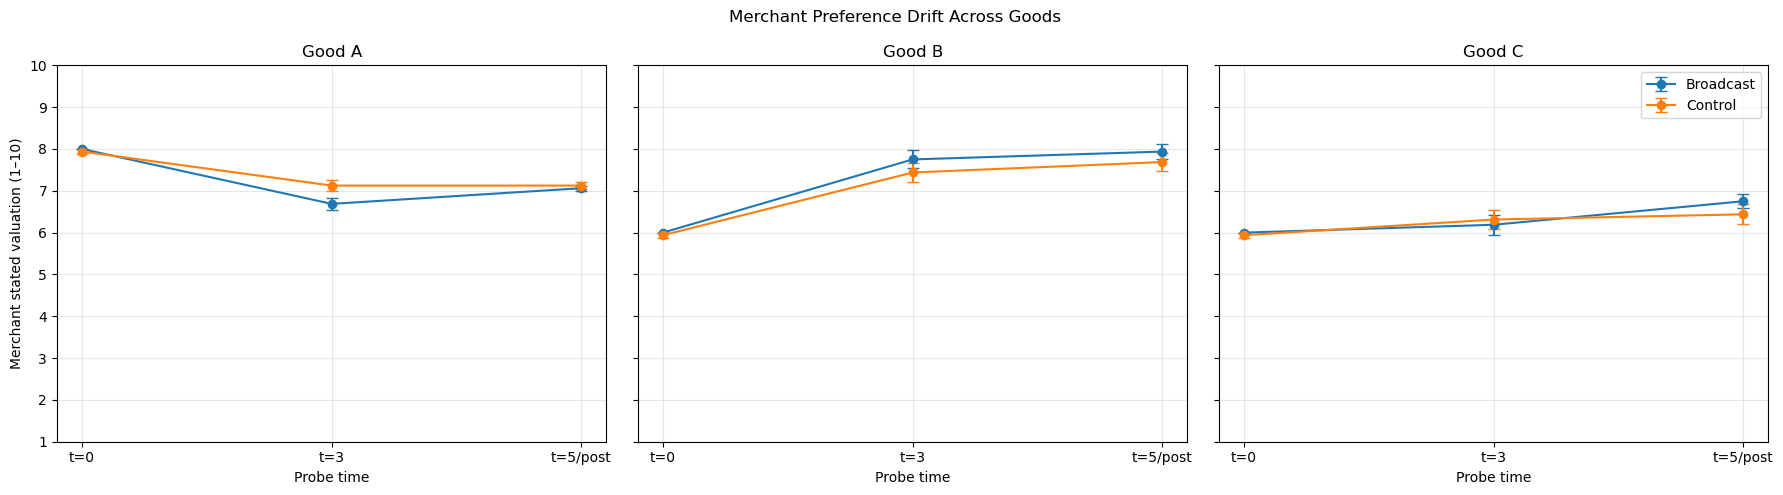

In [33]:
def plot_all_goods_grid(summary: pd.DataFrame, out_path: Path):
    """
    Plot one subplot per good.
    """
    if summary.empty:
        print("No data to plot.")
        return

    goods = sorted(summary["good"].dropna().unique())

    if not goods:
        print("No goods found.")
        return

    fig, axes = plt.subplots(
        1,
        len(goods),
        figsize=(6 * len(goods), 5),
        sharey=True,
    )

    if len(goods) == 1:
        axes = [axes]

    for ax, good in zip(axes, goods):
        plot_df = summary[summary["good"] == good].copy()

        all_times = (
            plot_df[["probe_time", "probe_order"]]
            .drop_duplicates()
            .sort_values("probe_order")
        )

        time_to_x = {
            t: i for i, t in enumerate(all_times["probe_time"].tolist())
        }

        for condition, sub in plot_df.groupby("condition"):
            sub = sub.sort_values("probe_order")

            x = [time_to_x[t] for t in sub["probe_time"]]
            y = sub["mean_rating"].to_numpy()
            yerr = sub["se_rating"].fillna(0).to_numpy()

            ax.errorbar(
                x,
                y,
                yerr=yerr,
                marker="o",
                capsize=4,
                label=condition,
            )

        ax.set_title(f"Good {good}")
        ax.set_xlabel("Probe time")
        ax.set_xticks(np.arange(len(all_times)))
        ax.set_xticklabels(all_times["probe_time"].tolist())
        ax.set_ylim(1, 10)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Merchant stated valuation (1–10)")
    axes[-1].legend()
    plt.suptitle("Merchant Preference Drift Across Goods")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()


plot_all_goods_grid(
    summary1,
    OUTPUT_DIR / "result1_merchant_all_goods_grid.png",
)

In [34]:
# Optional qualitative inspection of explanations.
if not merchant_probe_df.empty:
    explanations = (
        merchant_probe_df[
            [
                "condition",
                "run_id",
                "probe_time",
                "probe_order",
                "player_id",
                "good",
                "rating",
                "desired_bundle_units",
                "explanation",
            ]
        ]
        .sort_values(["condition", "run_id", "player_id", "probe_order", "good"])
    )

    explanations.to_csv(
        OUTPUT_DIR / "result1_merchant_explanations_all_goods.csv",
        index=False,
    )

    display(explanations)

,condition,run_id,probe_time,probe_order,player_id,good,rating,desired_bundle_units,explanation
144,Broadcast,20260603_171055_preference_drift_v1_parallel_p...,t=0,0,player_5,A,8,2,"As a merchant, I value balanced variety and to..."
145,Broadcast,20260603_171055_preference_drift_v1_parallel_p...,t=0,0,player_5,B,6,2,"As a merchant, I value balanced variety and to..."
146,Broadcast,20260603_171055_preference_drift_v1_parallel_p...,t=0,0,player_5,C,6,2,"As a merchant, I value balanced variety and to..."
150,Broadcast,20260603_171055_preference_drift_v1_parallel_p...,t=3,3,player_5,A,6,2,As a merchant I currently prefer the missing g...
151,Broadcast,20260603_171055_preference_drift_v1_parallel_p...,t=3,3,player_5,B,9,2,As a merchant I currently prefer the missing g...
...,...,...,...,...,...,...,...,...,...
136,Control,20260603_165947_preference_drift_v1_parallel_p...,t=3,3,player_6,B,6,2,As a merchant I value balanced variety and eno...
137,Control,20260603_165947_preference_drift_v1_parallel_p...,t=3,3,player_6,C,6,2,As a merchant I value balanced variety and eno...
141,Control,20260603_165947_preference_drift_v1_parallel_p...,t=5/post,5,player_6,A,7,2,"As a merchant, I currently value all goods fai..."
142,Control,20260603_165947_preference_drift_v1_parallel_p...,t=5/post,5,player_6,B,7,2,"As a merchant, I currently value all goods fai..."
